In [2]:
# import zipfile
import os


In [3]:
# !pip uninstall numpy -y
# !pip install 'numpy < 2'



In [4]:
# 1. Core Data and Image Processing Libraries
!pip install pandas opencv-python matplotlib seaborn scikit-learn tqdm watermark Pillow ultralytics



Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


In [5]:
# from google.colab import drive
# import os

# # Mount Google Drive
# drive.mount('/content/drive')



In [6]:
# Prepare path variable for the dataset
dataset_path = './kaggle_dataset/2020-02-14_InfraredSolarModules/InfraredSolarModules/images' # Replace with your actual dataset path

# Verify the path (optional)
if os.path.exists(dataset_path):
    print(f"Dataset path found: {dataset_path}")
else:
    print(f"Dataset path not found: {dataset_path}. Please check the path.")

Dataset path found: ./kaggle_dataset/2020-02-14_InfraredSolarModules/InfraredSolarModules/images


In [7]:
import json

json_path = './kaggle_dataset/2020-02-14_InfraredSolarModules/InfraredSolarModules/module_metadata.json'

try:
    with open(json_path, 'r') as f:
        metadata = json.load(f)
    #print(metadata)
except FileNotFoundError:
    print(f"File not found: {json_path}")
except json.JSONDecodeError:
    print(f"Error decoding JSON from file: {json_path}")

In [8]:
# 2. Deep Learning Libraries (PyTorch)
# Use this command for a standard installation on a machine without a powerful NVIDIA GPU
# !pip install torch torchvision

# OR, use this for NVIDIA CUDA support (check the official PyTorch site for your specific CUDA version)
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [9]:
from watermark import *
print(watermark())
print(watermark(packages="pandas,opencv-python,numpy,matplotlib,seaborn,scikit-learn,tqdm,watermark,Pillow,torch"))

Last updated: 2025-11-16T16:35:06.450300+01:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 8.21.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.1.0-38-amd64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

pandas       : 2.2.3
opencv-python: not installed
numpy        : 1.24.3
matplotlib   : 3.10.0
seaborn      : 0.13.2
scikit-learn : 1.5.0
tqdm         : 4.67.0
watermark    : 2.4.3
Pillow       : not installed
torch        : 2.3.0a0+6ddf5cf85e.nv24.4



## Initialize and Load YOLOv8 Model

### Subtask:
Import the YOLO class from the ultralytics library, initialize a YOLOv8m model, and confirm its readiness for training.


**Reasoning**:
Import the YOLO class from ultralytics and initialize a YOLOv8m model to prepare for training.



In [10]:
from ultralytics import YOLO

data_yaml_path="./kaggle_dataset/2020-02-14_InfraredSolarModules/InfraredSolarModules/yolov8_dataset/data.yaml"

# Initialize a YOLOv8m model
model = YOLO('./runs/detect/train2/weights/best.pt')

# Print the model to confirm its readiness
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_

## Evaluate Trained Model

### Subtask:
Evaluate the performance of the trained YOLOv8 model on the test set to assess its accuracy and generalization capabilities.


**Reasoning**:
Evaluate the trained YOLOv8 model on the test set using the `val()` method with the specified data configuration and image size.



In [11]:
metrics = model.val(data=data_yaml_path, imgsz=640)
print(metrics)

Ultralytics YOLOv8.2.35 🚀 Python-3.10.12 torch-2.3.0a0+6ddf5cf85e.nv24.04 CUDA:0 (NVIDIA A40, 45488MiB)
Model summary (fused): 218 layers, 25846708 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning /auto/vestec1-elixir/home/schatzm/SolarPanels/kaggle_dataset/2020-02-14_InfraredSolarModules/InfraredSolarModules/yolov8_dataset/labels/val.cache... 2000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2000/2000 [00:00<?, ?it/s]
/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 125/125 [00:11<00:00, 11.11it/s]


                   all       2000       2000      0.764      0.761      0.812      0.812
                  Cell        188        188      0.659      0.782      0.805      0.805
            Cell-Multi        129        129      0.641      0.513      0.631      0.631
              Cracking         94         94      0.734      0.766      0.813      0.813
                 Diode        150        150      0.974      0.989      0.993      0.993
           Diode-Multi         18         18          1      0.879       0.97       0.97
              Hot-Spot         25         25      0.659        0.6      0.707      0.707
        Hot-Spot-Multi         24         24      0.537       0.58      0.606      0.606
            No-Anomaly       1000       1000      0.933      0.985      0.985      0.985
        Offline-Module         82         82      0.788      0.756      0.833      0.833
             Shadowing        105        105      0.814      0.781      0.881      0.881
               Soilin

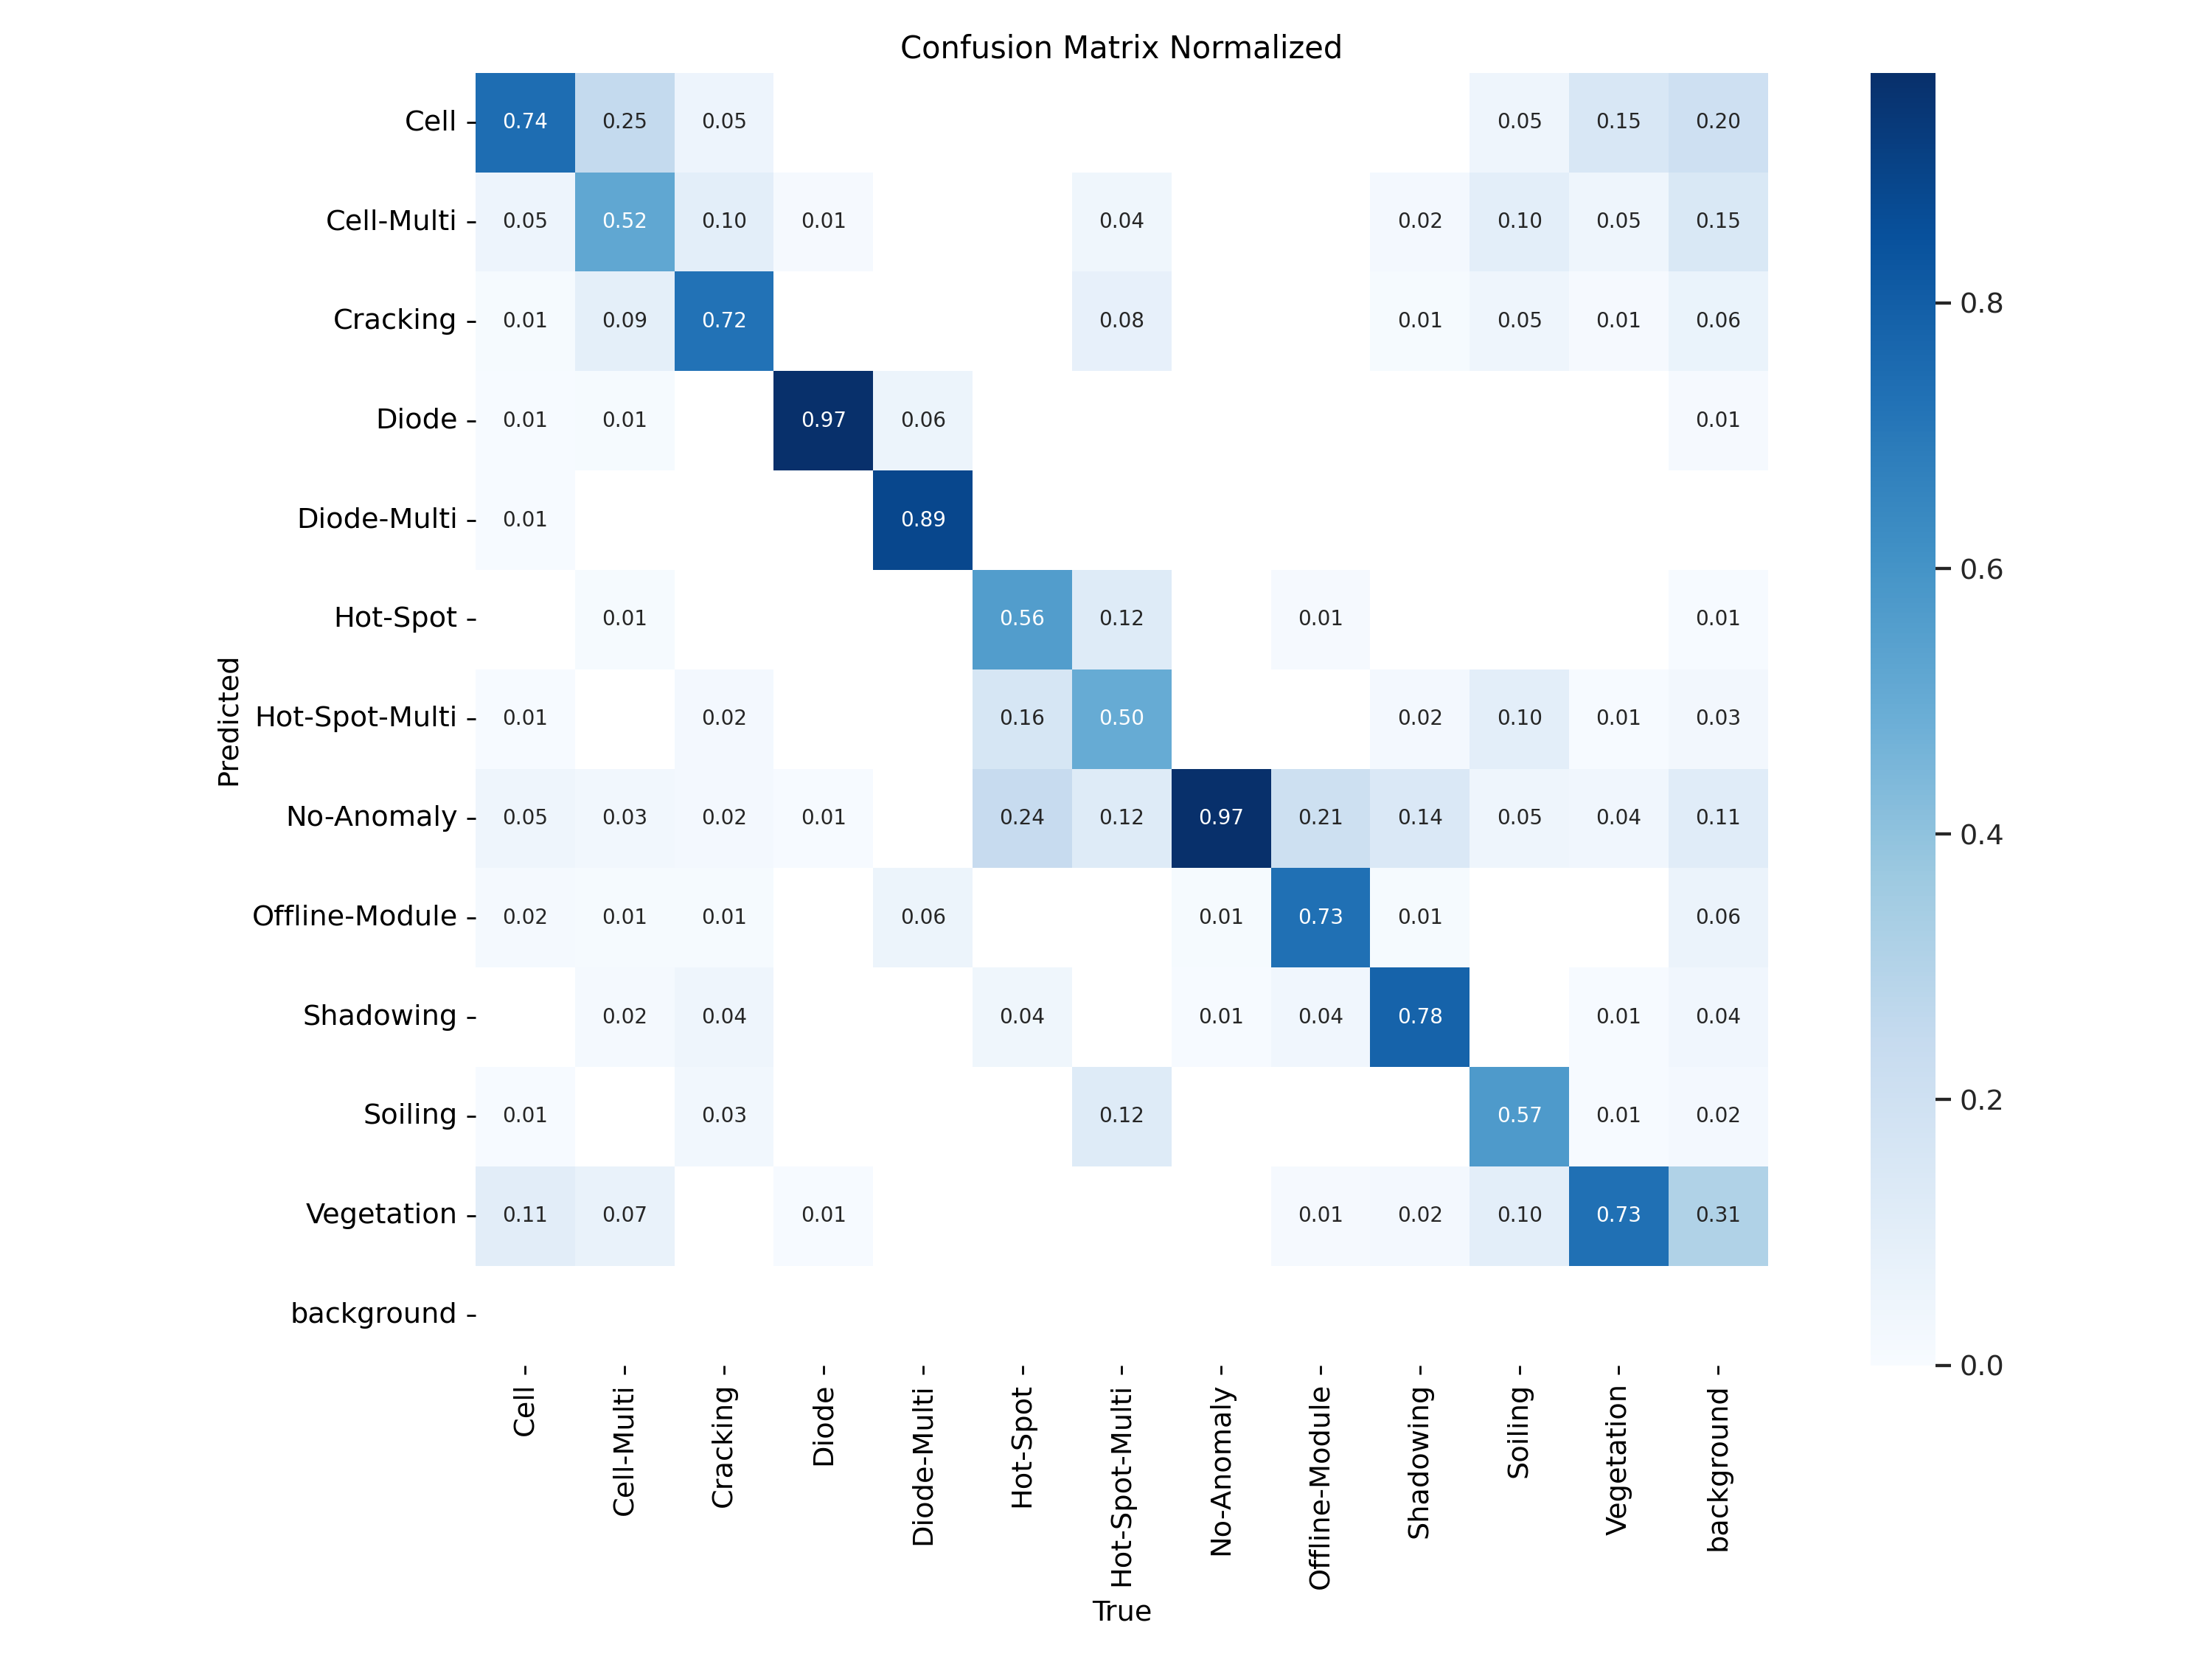

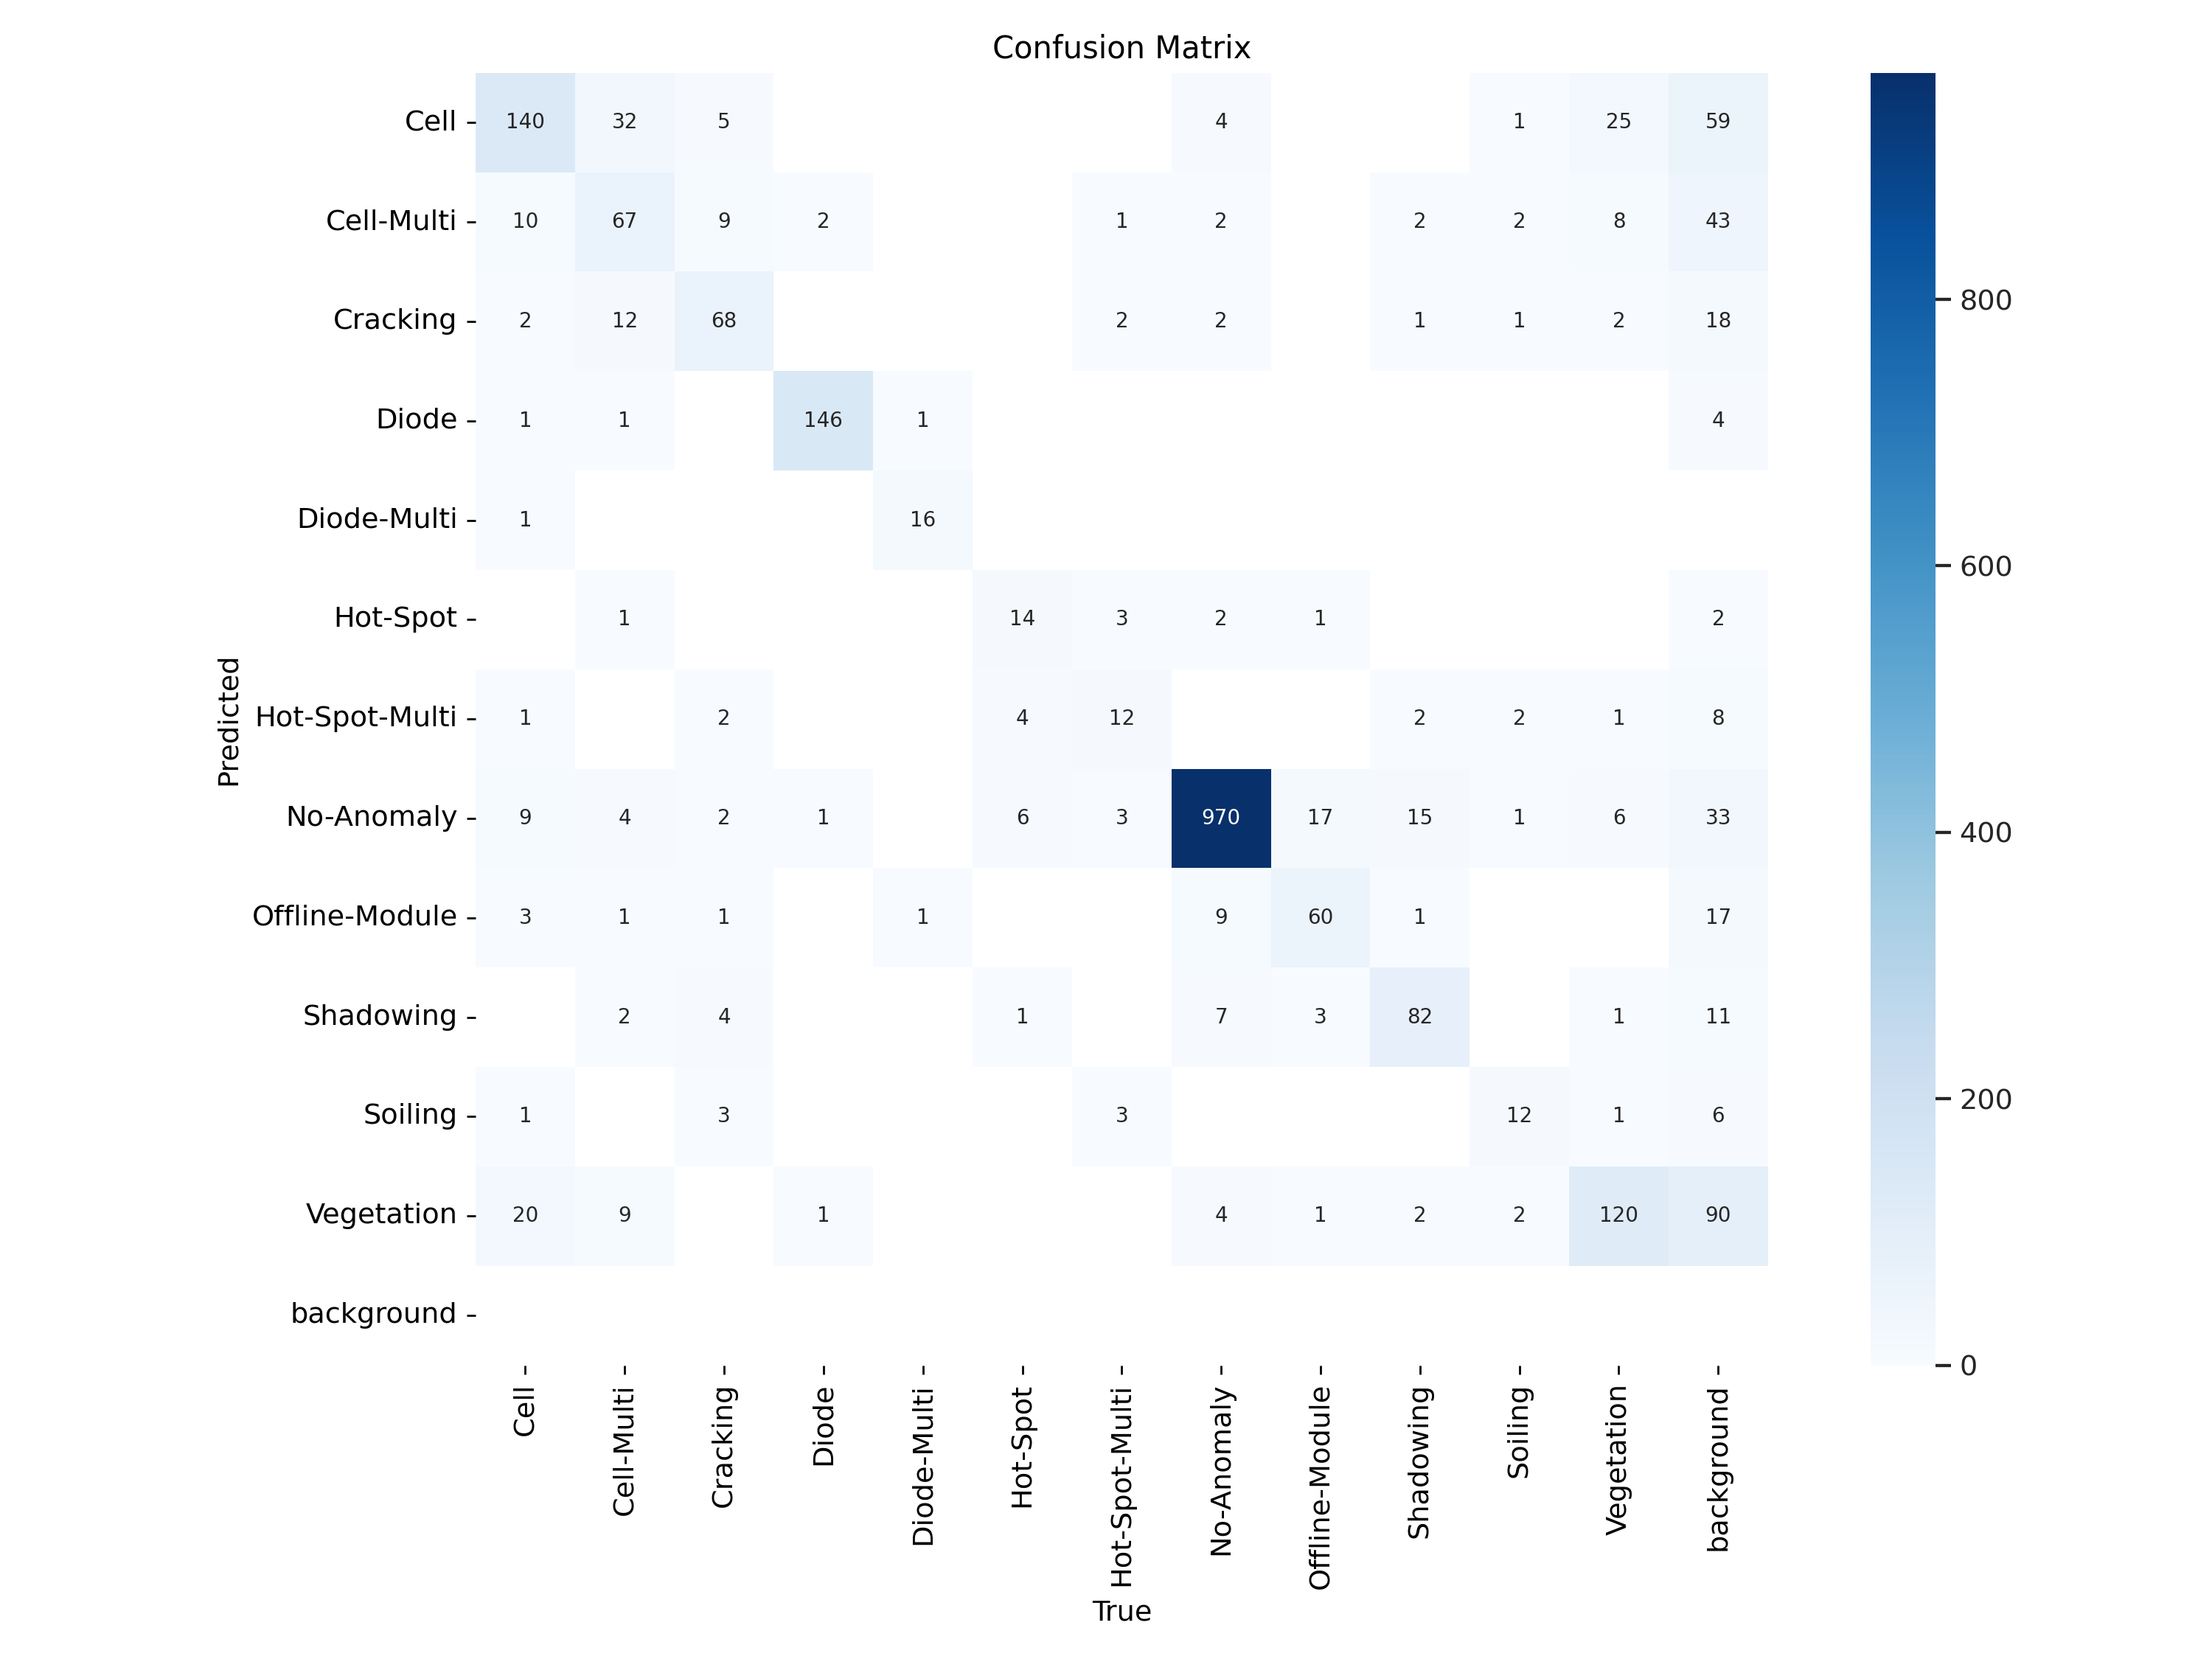

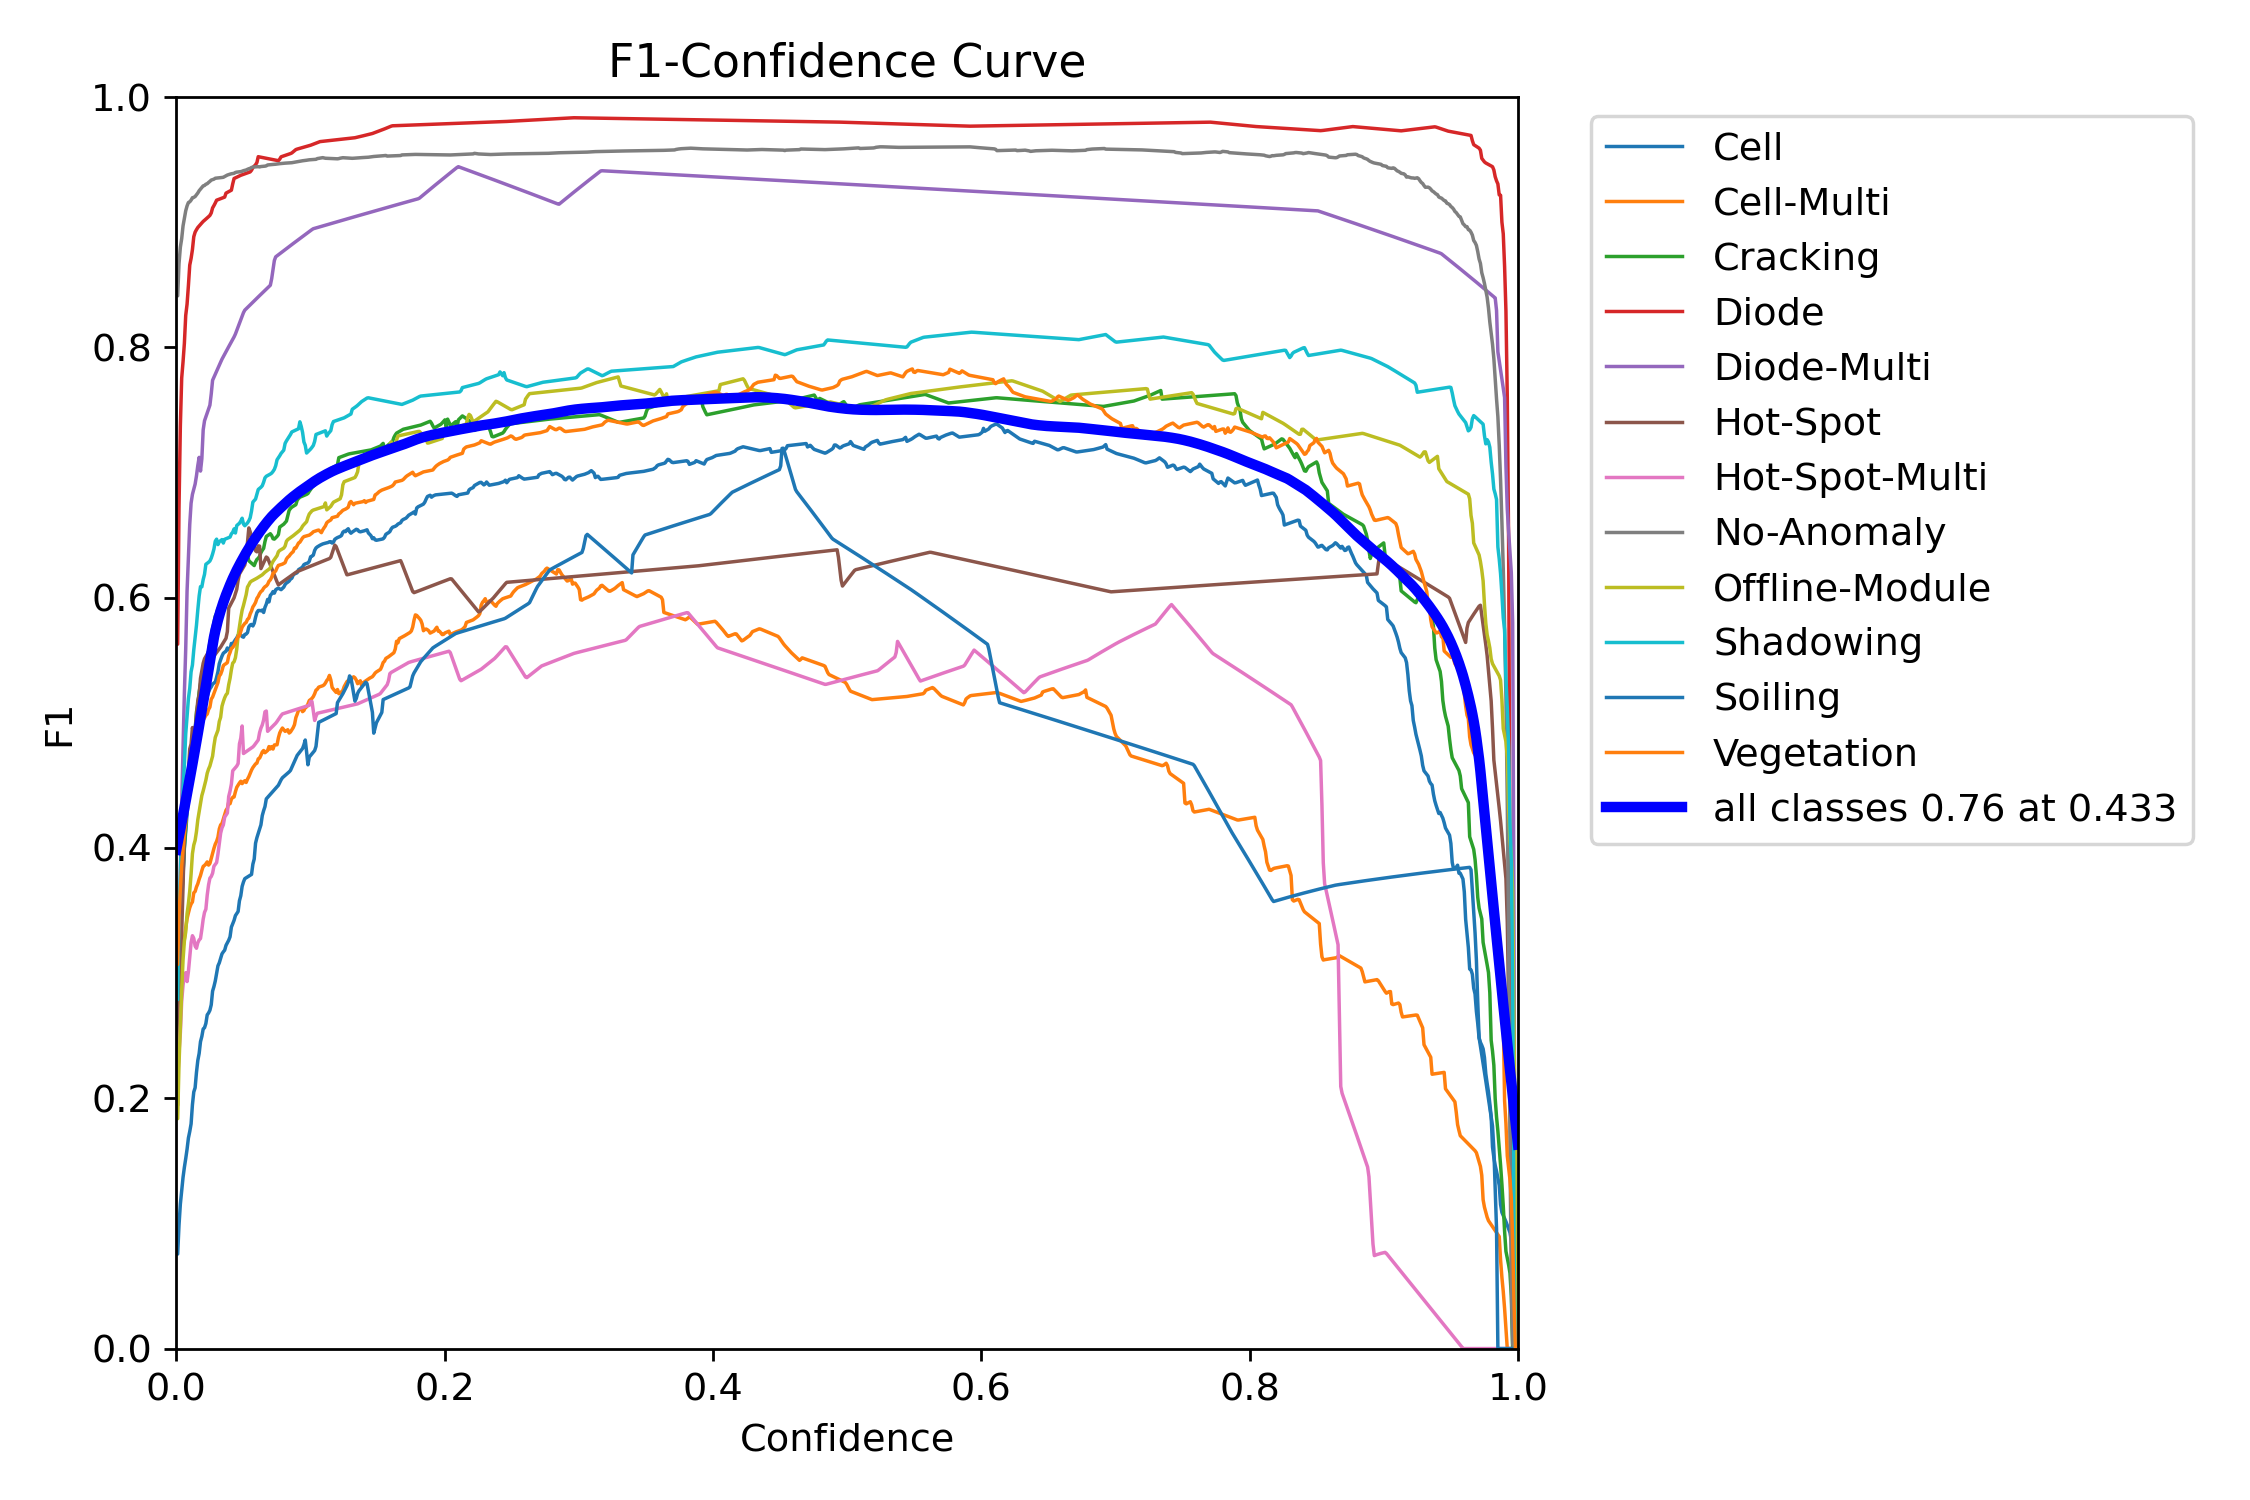